In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('mnist_train.csv')

In [3]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [5]:
df.dtypes

label    int64
1x1      int64
1x2      int64
1x3      int64
1x4      int64
         ...  
28x24    int64
28x25    int64
28x26    int64
28x27    int64
28x28    int64
Length: 785, dtype: object

In [6]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [7]:
X = df.drop('label',axis=1)
y = df['label']

In [8]:
X = X.astype('float32')/255.0

In [9]:
X = X.to_numpy()
y = y.to_numpy(dtype='int32')

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
from tensorflow import keras
model = keras.Sequential([
    keras.layers.Dense(128,activation='relu',input_shape=(784,)),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
1500/1500 [==============================] - 7s 4ms/step - loss: 0.2681 - accuracy: 0.9221
Epoch 2/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1126 - accuracy: 0.9653
Epoch 3/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0769 - accuracy: 0.9766
Epoch 4/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0607 - accuracy: 0.9818
Epoch 5/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0451 - accuracy: 0.9856
Epoch 6/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0378 - accuracy: 0.9875
Epoch 7/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0303 - accuracy: 0.9906
Epoch 8/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0269 - accuracy: 0.9909
Epoch 9/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0230 - accuracy: 0.9924
Epoch 10/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.019

In [14]:
model.evaluate(X_test,y_test)

375/375 [==============================] - 2s 3ms/step - loss: 0.1099 - accuracy: 0.9737


[0.10991214960813522, 0.9737499952316284]

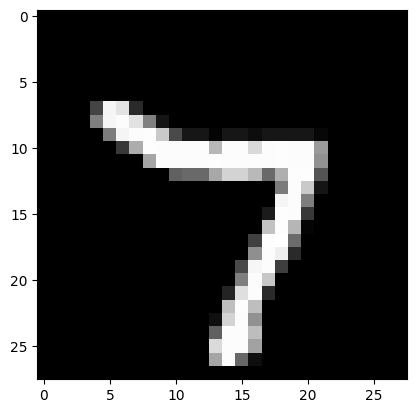

1/1 [==============================] - 0s 157ms/step
[[7.6885370e-14 9.3576541e-15 1.0114365e-15 1.5474508e-12 1.1835122e-17
  4.9725455e-14 2.6625116e-17 1.0000000e+00 2.8370385e-19 2.3528868e-10]]


In [15]:
import matplotlib.pyplot as plt
plt.imshow(X_test[0].reshape(28,28),cmap='grey')
plt.show()
print(model.predict(X_test[0].reshape(1,784)))

In [16]:
model.save('mnist_model.h5')